In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import RobustScaler
from sklearn.ensemble        import IsolationForest
from sklearn.decomposition   import PCA
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
DATASET_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_application_data.csv"
LABEL_COLUMN = "Label"
BENIGN_LABEL = "Benign"

MODELS_DIR  = "models"
RESULTS_DIR = os.path.join("results", "layer2_unsup")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SIZE   = 0.20
VAL_SIZE    = 0.10
RANDOM_SEED = 42

# Isolation Forest
IF_N_ESTIMATORS = 300
IF_MAX_SAMPLES  = "auto"

# Unknown attack definition
UNKNOWN_FRACTION       = 0.10   # Option A: rarest 10% of classes
UNKNOWN_ATTACK_CLASSES = []     # Option B: explicit list (overrides A)

APPLICATION_FEATURES = [
    "Pkt Size Avg",
    "Pkt Len Mean",
    "Pkt Len Max",
    "Pkt Len Min",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Fwd Seg Size Min",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg",
    "TotLen Fwd Pkts",
    "Subflow Fwd Byts"
]

In [3]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
df.columns       = df.columns.str.strip()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

df_atk = df[df[LABEL_COLUMN] != BENIGN_LABEL].copy().reset_index(drop=True)
print(f"Total rows  : {len(df):,}")
print(f"Attack rows : {len(df_atk):,}  (benign dropped)")

found   = [f for f in APPLICATION_FEATURES if f in df_atk.columns]
missing = [f for f in APPLICATION_FEATURES if f not in df_atk.columns]
print(f"\nFeatures found   : {len(found)} / {len(APPLICATION_FEATURES)}")
if missing: print(f"Features missing : {missing}")

counts = df_atk[LABEL_COLUMN].value_counts()
print("\nAttack class distribution:")
for cls, cnt in counts.items():
    bar = chr(9608) * int(30 * cnt / counts.max())
    print(f"  {cls:<38}  {cnt:>8,}  {bar}")

X      = df_atk[found].values.astype(np.float64)
labels = df_atk[LABEL_COLUMN].reset_index(drop=True)

Total rows  : 6,870,587
Attack rows : 2,748,235  (benign dropped)

Features found   : 19 / 19

Attack class distribution:
  DDOS attack-HOIC                         686,012  ██████████████████████████████
  DDoS attacks-LOIC-HTTP                   576,191  █████████████████████████
  DoS attacks-Hulk                         461,912  ████████████████████
  Bot                                      286,191  ████████████
  FTP-BruteForce                           193,360  ████████
  SSH-Bruteforce                           187,589  ████████
  Infilteration                            161,934  ███████
  DoS attacks-SlowHTTPTest                 139,890  ██████
  DoS attacks-GoldenEye                     41,508  █
  DoS attacks-Slowloris                     10,990  
  DDOS attack-LOIC-UDP                       1,730  
  Brute Force -Web                             611  
  Brute Force -XSS                             230  
  SQL Injection                                 87  


In [4]:
all_classes = set(labels.unique())

if UNKNOWN_ATTACK_CLASSES:
    unknown = set(UNKNOWN_ATTACK_CLASSES) & all_classes
    print(f"Option B: {len(unknown)} explicit unknown class(es)")
else:
    n_unk   = max(1, int(len(all_classes) * UNKNOWN_FRACTION))
    unknown = set(counts.tail(n_unk).index)
    print(f"Option A: bottom {UNKNOWN_FRACTION*100:.0f}% rarest -> {n_unk} unknown")

known = all_classes - unknown

print(f"\nKnown   ({len(known)})  -> Layer 3  (seen during IF training):")
for c in sorted(known):   print(f"  +  {c}")
print(f"\nUnknown ({len(unknown)})  -> alert admin  (NEVER seen during training):")
for c in sorted(unknown): print(f"  -  {c}")

with open(os.path.join(MODELS_DIR,"layer2_unsupervised_known_classes.txt"),"w") as fh:
    for c in sorted(known): fh.write(c+"\n")
print(f"\nSaved -> {MODELS_DIR}/layer2_unsupervised_known_classes.txt")

Option A: bottom 10% rarest -> 1 unknown

Known   (13)  -> Layer 3  (seen during IF training):
  +  Bot
  +  Brute Force -Web
  +  Brute Force -XSS
  +  DDOS attack-HOIC
  +  DDOS attack-LOIC-UDP
  +  DDoS attacks-LOIC-HTTP
  +  DoS attacks-GoldenEye
  +  DoS attacks-Hulk
  +  DoS attacks-SlowHTTPTest
  +  DoS attacks-Slowloris
  +  FTP-BruteForce
  +  Infilteration
  +  SSH-Bruteforce

Unknown (1)  -> alert admin  (NEVER seen during training):
  -  SQL Injection

Saved -> models/layer2_unsupervised_known_classes.txt


In [5]:
y = labels.isin(known).astype(int).values

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, random_state=RANDOM_SEED, stratify=y_tv)

n_known   = (y_train == 1).sum()
n_unknown = (y_train == 0).sum()
ratio     = n_known / max(n_unknown, 1)

print(f"Train      — Known: {n_known:,}  Unknown: {n_unknown:,}  ratio: {ratio:.1f}:1")
print(f"Validation — {len(y_val):,} samples")
print(f"Test       — {len(y_test):,} samples")

if ratio > 10:
    print("\n[!] WARNING: Heavy class imbalance detected.")
    print("    Isolation Forest may suffer from Scenario B (imbalance trap).")
    print("    Consider the supervised Layer 2 for better results.")

Train      — Known: 1,923,703  Unknown: 61  ratio: 31536.1:1
Validation — 274,824 samples
Test       — 549,647 samples

[!] WARNING: Heavy class imbalance detected.
    Isolation Forest may suffer from Scenario B (imbalance trap).
    Consider the supervised Layer 2 for better results.


In [6]:
scaler_path = os.path.join(MODELS_DIR, "/home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl")
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print(f"Loaded Layer 1 scaler <- {scaler_path}")
else:
    scaler = RobustScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, os.path.join(MODELS_DIR,"layer2_unsupervised_scaler.pkl"))
    print("New RobustScaler fitted and saved.")

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print(f"Scaled: Train{X_train_s.shape}  Val{X_val_s.shape}  Test{X_test_s.shape}")

Loaded Layer 1 scaler <- /home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl
Scaled: Train(1923764, 19)  Val(274824, 19)  Test(549647, 19)


In [7]:
X_known       = X_train_s[y_train == 1]
n_total       = len(y_train)
n_unk_train   = (y_train == 0).sum()
contamination = float(np.clip(n_unk_train / n_total, 0.01, 0.499))

print(f"Known training samples : {len(X_known):,}")
print(f"contamination param    : {contamination:.4f}  (true unknown fraction)")

t0 = time.time()
model = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    max_samples=IF_MAX_SAMPLES,
    contamination=contamination,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
model.fit(X_known)
print(f"Training done in {time.time()-t0:.1f}s")

joblib.dump(model, os.path.join(MODELS_DIR,"layer2_unsupervised_isolation_forest.pkl"))
print(f"Saved -> {MODELS_DIR}/layer2_unsupervised_isolation_forest.pkl")

Known training samples : 1,923,703
contamination param    : 0.0100  (true unknown fraction)
Training done in 17.7s
Saved -> models/layer2_unsupervised_isolation_forest.pkl


In [8]:
val_scores = model.decision_function(X_val_s)

val_prec, val_rec, val_thr = precision_recall_curve(y_val, val_scores)
val_f1s = 2 * val_prec * val_rec / (val_prec + val_rec + 1e-9)
best_i  = int(np.argmax(val_f1s[:-1]))
threshold = float(val_thr[best_i])

preds_check    = (val_scores >= threshold).astype(int)
n_pred_unknown = (preds_check == 0).sum()
n_pred_known   = (preds_check == 1).sum()

print(f"Best threshold (max F1) : {threshold:.6f}")
print(f"Val F1 at threshold     : {val_f1s[best_i]:.4f}")
print(f"Predicted Known         : {n_pred_known:,}")
print(f"Predicted Unknown       : {n_pred_unknown:,}")

# ── Scenario C detection & fallback ──────────────────────────────
if n_pred_unknown == 0:
    print("\n[!] SCENARIO C DETECTED: threshold produces 0 Unknown predictions.")
    print("    Precision=1.0 for Known is a threshold artefact, not real performance.")
    mean_known   = val_scores[y_val == 1].mean()
    mean_unknown = val_scores[y_val == 0].mean() if (y_val==0).sum()>0 else val_scores.min()
    threshold    = float((mean_known + mean_unknown) / 2)
    fallback_f1  = f1_score(y_val, (val_scores>=threshold).astype(int), zero_division=0)
    print(f"    Fallback midpoint threshold : {threshold:.6f}  F1={fallback_f1:.4f}")
else:
    print("\nNo Scenario C detected — threshold is valid.")

with open(os.path.join(MODELS_DIR,"layer2_unsupervised_threshold.txt"),"w") as fh:
    fh.write(str(threshold))
print(f"Threshold saved -> {MODELS_DIR}/layer2_unsupervised_threshold.txt")

Best threshold (max F1) : -0.096830
Val F1 at threshold     : 1.0000
Predicted Known         : 274,824
Predicted Unknown       : 0

[!] SCENARIO C DETECTED: threshold produces 0 Unknown predictions.
    Precision=1.0 for Known is a threshold artefact, not real performance.
    Fallback midpoint threshold : 0.191543  F1=0.9098
Threshold saved -> models/layer2_unsupervised_threshold.txt


In [9]:
test_scores = model.decision_function(X_test_s)
preds       = (test_scores >= threshold).astype(int)

acc  = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, zero_division=0)
rec  = recall_score(y_test,    preds, zero_division=0)
f1   = f1_score(y_test,        preds, zero_division=0)
try:    auc = roc_auc_score(y_test, test_scores)
except: auc = None

print(f"Accuracy  : {acc*100:.4f}%")
print(f"Precision : {prec:.4f}   Recall : {rec:.4f}   F1 : {f1:.4f}")
if auc: print(f"ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y_test, preds,
      target_names=["Unknown","Known"], digits=4, zero_division=0))

# ── Precision = 1.0 diagnosis ─────────────────────────────────────
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()
per_cls_prec = precision_score(y_test, preds, average=None, zero_division=0)
per_cls_rec  = recall_score(y_test,    preds, average=None, zero_division=0)

print("\n── Precision = 1.0 Diagnosis ──")
for cls_i, cls_name in enumerate(["Unknown", "Known"]):
    p = per_cls_prec[cls_i]
    r = per_cls_rec[cls_i]
    if abs(p - 1.0) < 1e-6:
        pred_count = (preds == cls_i).sum()
        true_count = (y_test == cls_i).sum()
        print(f"\n  {cls_name}: Precision = 1.0")
        print(f"    True samples          : {true_count:,}")
        print(f"    Predicted as {cls_name:<8}: {pred_count:,}")
        if pred_count == 0:
            print(f"    -> SCENARIO C: 0 predictions for this class.")
            print(f"       precision=1.0 is a zero_division artefact.")
            print(f"       Recall={r:.4f}. This class is being ignored.")
        elif r > 0.95:
            print(f"    -> SCENARIO A: Genuine separation.")
            print(f"       Recall={r:.4f} is also high — real result.")
        else:
            print(f"    -> SCENARIO B: Imbalance trap likely.")
            print(f"       Recall={r:.4f} is low. Model predicts this class")
            print(f"       often but misses the other class badly.")

print(f"\nConfusion Matrix:")
print(f"  TN (Unknown correctly flagged) : {tn:,}")
print(f"  FP (Unknown called Known)      : {fp:,}")
print(f"  FN (Known called Unknown)      : {fn:,}")
print(f"  TP (Known correctly identified): {tp:,}")

Accuracy  : 83.3781%
Precision : 1.0000   Recall : 0.8338   F1 : 0.9094
ROC-AUC   : 0.6509

              precision    recall  f1-score   support

     Unknown     0.0001    0.5882    0.0002        17
       Known     1.0000    0.8338    0.9094    549630

    accuracy                         0.8338    549647
   macro avg     0.5000    0.7110    0.4548    549647
weighted avg     1.0000    0.8338    0.9093    549647


── Precision = 1.0 Diagnosis ──

Confusion Matrix:
  TN (Unknown correctly flagged) : 10
  FP (Unknown called Known)      : 7
  FN (Known called Unknown)      : 91,355
  TP (Known correctly identified): 458,275


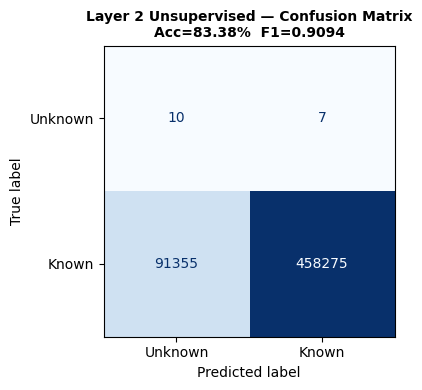

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                       display_labels=["Unknown","Known"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Layer 2 Unsupervised — Confusion Matrix\n"
             f"Acc={acc*100:.2f}%  F1={f1:.4f}",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()

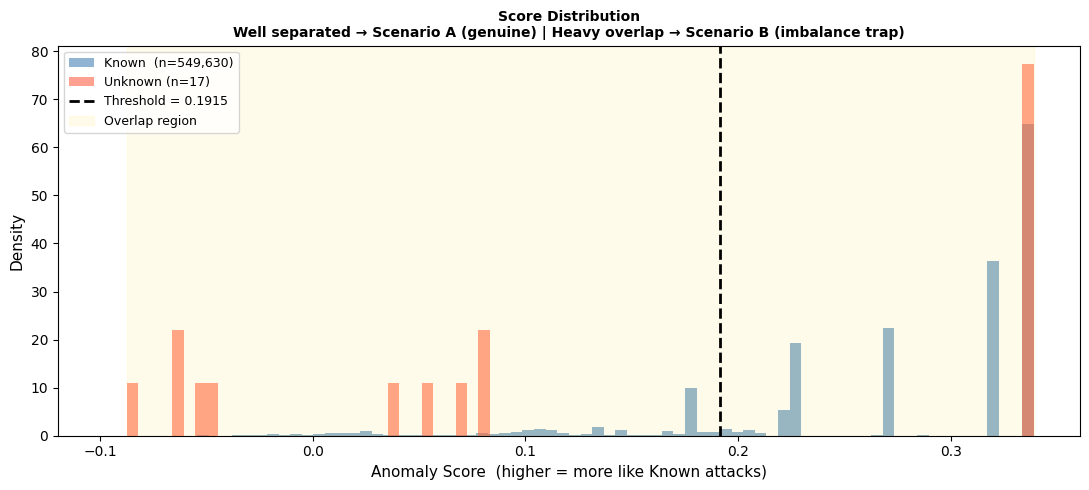

In [11]:
s_known   = test_scores[y_test == 1]
s_unknown = test_scores[y_test == 0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(s_known,   bins=80, alpha=0.6, color="steelblue",
        label=f"Known  (n={len(s_known):,})", density=True)
ax.hist(s_unknown, bins=80, alpha=0.6, color="tomato",
        label=f"Unknown (n={len(s_unknown):,})", density=True)
ax.axvline(threshold, color="black", linestyle="--", lw=2,
           label=f"Threshold = {threshold:.4f}")

overlap_lo = max(s_unknown.min(), s_known.min())
overlap_hi = min(s_unknown.max(), s_known.max())
if overlap_lo < overlap_hi:
    ax.axvspan(overlap_lo, overlap_hi, alpha=0.08,
               color="gold", label="Overlap region")

ax.set_xlabel("Anomaly Score  (higher = more like Known attacks)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Score Distribution\n"
             "Well separated → Scenario A (genuine) | "
             "Heavy overlap → Scenario B (imbalance trap)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_score_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

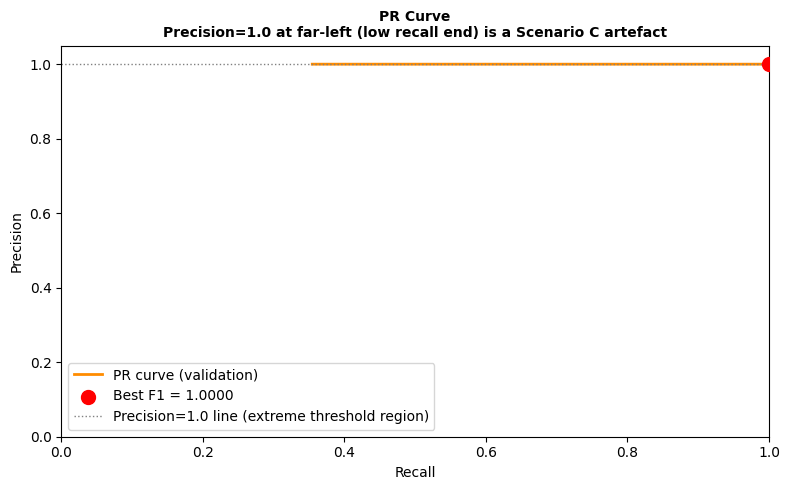

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(val_rec[:-1], val_prec[:-1], color="darkorange", lw=2,
        label="PR curve (validation)")
ax.scatter(val_rec[best_i], val_prec[best_i], color="red", s=100,
           zorder=5, label=f"Best F1 = {val_f1s[best_i]:.4f}")
ax.axhline(1.0, color="grey", linestyle=":", lw=1,
           label="Precision=1.0 line (extreme threshold region)")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR Curve\n"
             "Precision=1.0 at far-left (low recall end) is a Scenario C artefact",
             fontsize=10, fontweight="bold")
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_pr_curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()

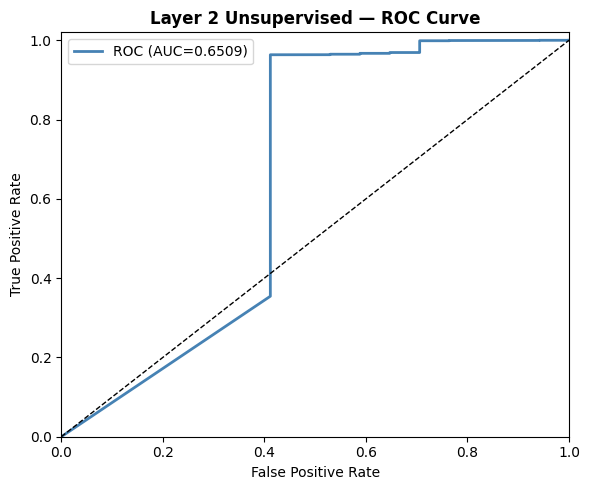

In [13]:
try:
    fpr, tpr, _ = roc_curve(y_test, test_scores)
    roc_auc = roc_auc_score(y_test, test_scores)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="steelblue", lw=2,
            label=f"ROC (AUC={roc_auc:.4f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("Layer 2 Unsupervised — ROC Curve", fontweight="bold")
    ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_roc_curve.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"ROC curve skipped: {e}")

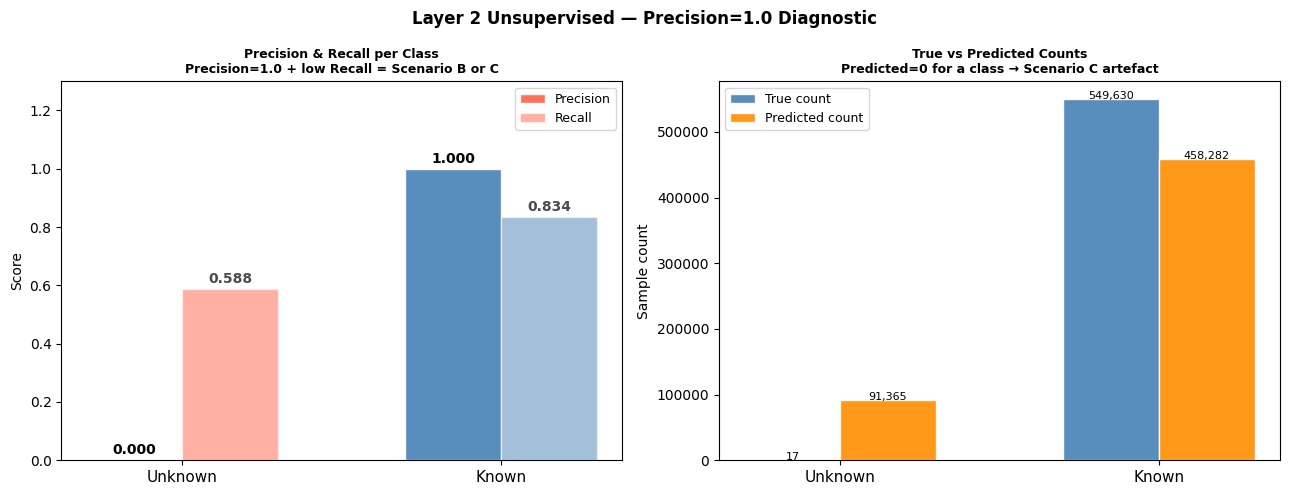

In [14]:
per_p = precision_score(y_test, preds, average=None, zero_division=0)
per_r = recall_score(y_test,    preds, average=None, zero_division=0)
pred_counts = [(preds==0).sum(), (preds==1).sum()]
true_counts = [(y_test==0).sum(), (y_test==1).sum()]

x, w = np.arange(2), 0.3
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Precision & Recall
axes[0].bar(x,   per_p, w, color=["tomato","steelblue"],
            edgecolor="white", label="Precision", alpha=0.9)
axes[0].bar(x+w, per_r, w, color=["tomato","steelblue"],
            edgecolor="white", label="Recall",    alpha=0.5)
for i,(p_,r_) in enumerate(zip(per_p,per_r)):
    axes[0].text(i,   p_+0.02, f"{p_:.3f}", ha="center",
                 fontsize=10, fontweight="bold")
    axes[0].text(i+w, r_+0.02, f"{r_:.3f}", ha="center",
                 fontsize=10, fontweight="bold", alpha=0.7)
axes[0].set_xticks(x+w/2)
axes[0].set_xticklabels(["Unknown","Known"], fontsize=11)
axes[0].set_ylim(0, 1.3); axes[0].set_ylabel("Score")
axes[0].set_title("Precision & Recall per Class\n"
                  "Precision=1.0 + low Recall = Scenario B or C",
                  fontsize=9, fontweight="bold")
axes[0].legend(fontsize=9)

# Right: True vs Predicted counts
axes[1].bar(x,   true_counts, w, color="steelblue",
            edgecolor="white", label="True count",      alpha=0.9)
axes[1].bar(x+w, pred_counts, w, color="darkorange",
            edgecolor="white", label="Predicted count", alpha=0.9)
for i,(tc,pc) in enumerate(zip(true_counts,pred_counts)):
    axes[1].text(i,   tc+5,  f"{tc:,}", ha="center", fontsize=8)
    axes[1].text(i+w, pc+5,  f"{pc:,}", ha="center", fontsize=8)
    if pc == 0:
        axes[1].text(i+w, max(true_counts)*0.1, "Scenario C\n(0 preds)",
                     ha="center", fontsize=8, color="red", fontweight="bold")
axes[1].set_xticks(x+w/2)
axes[1].set_xticklabels(["Unknown","Known"], fontsize=11)
axes[1].set_ylabel("Sample count"); axes[1].legend(fontsize=9)
axes[1].set_title("True vs Predicted Counts\n"
                  "Predicted=0 for a class → Scenario C artefact",
                  fontsize=9, fontweight="bold")

plt.suptitle("Layer 2 Unsupervised — Precision=1.0 Diagnostic",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_precision_diagnostic.png"),
            dpi=150, bbox_inches="tight")
plt.show()

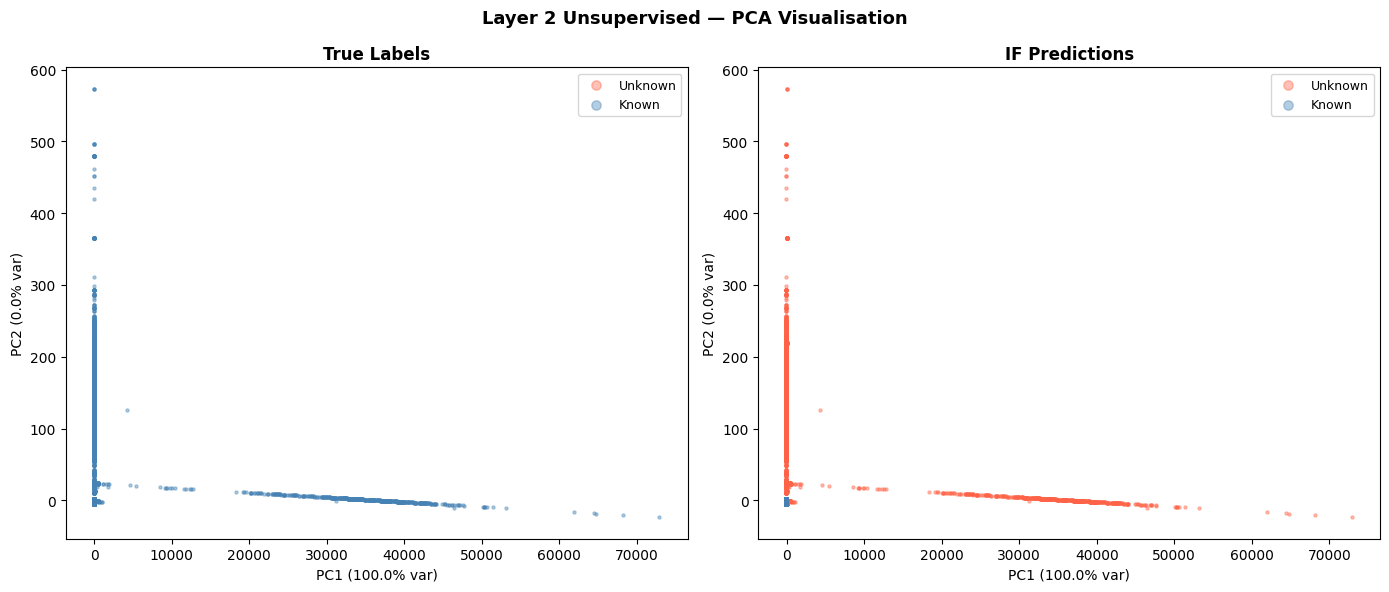

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X2d = pca.fit_transform(X_test_s)
var = pca.explained_variance_ratio_
cmap_ = {0:("Unknown","tomato"), 1:("Known","steelblue")}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (lbl, title) in zip(axes, [(y_test,"True Labels"),(preds,"IF Predictions")]):
    for cls,(cname,col) in cmap_.items():
        mask=(lbl==cls)
        ax.scatter(X2d[mask,0],X2d[mask,1],c=col,s=5,alpha=0.4,label=cname)
    ax.set_xlabel(f"PC1 ({100*var[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({100*var[1]:.1f}% var)")
    ax.set_title(title, fontweight="bold"); ax.legend(markerscale=3,fontsize=9)
plt.suptitle("Layer 2 Unsupervised — PCA Visualisation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_pca.png"),
            dpi=150, bbox_inches="tight")
plt.show()

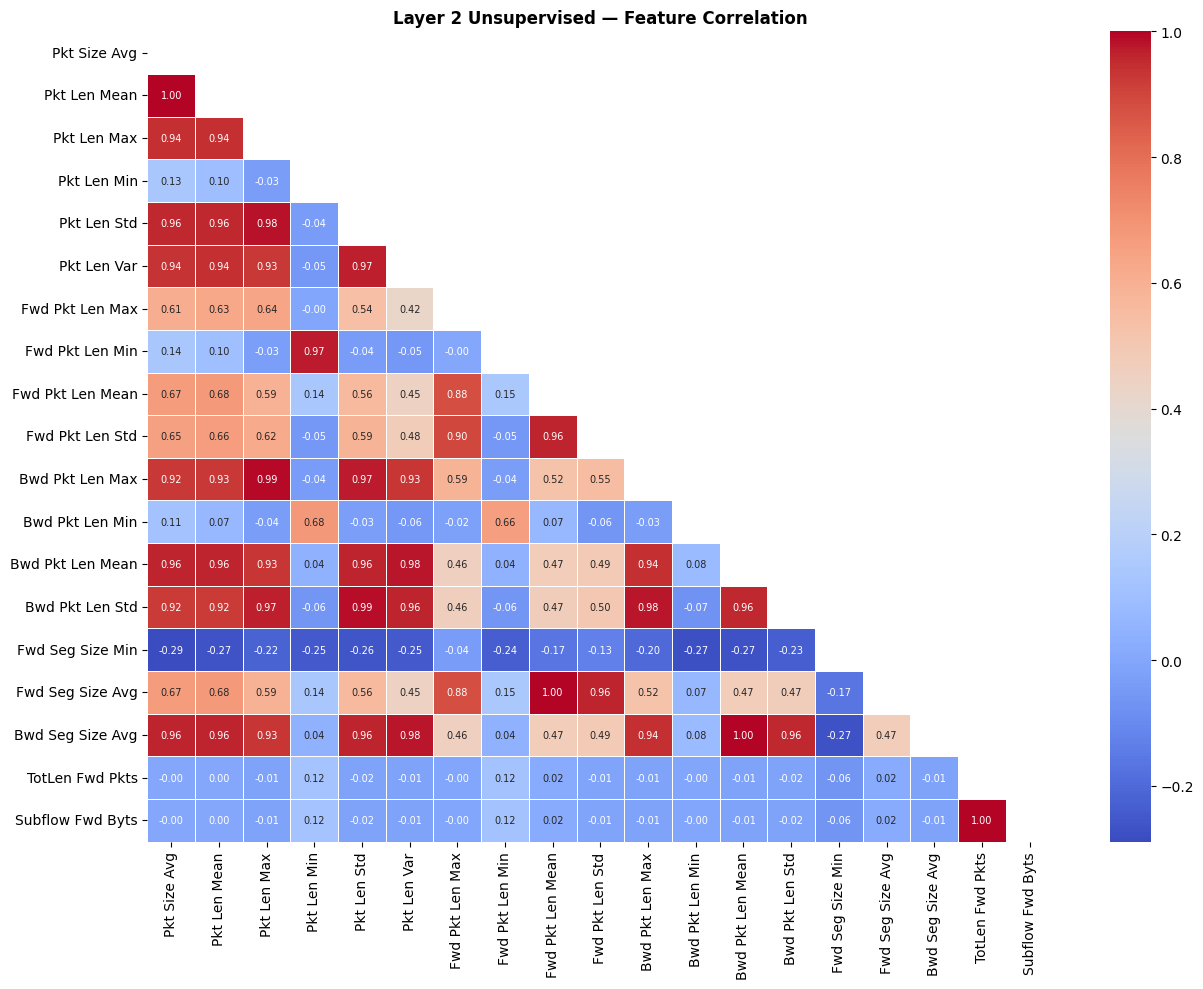

In [16]:
n_feat = len(found)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(pd.DataFrame(X_test_s, columns=found).corr(),
            mask=np.triu(np.ones((n_feat,n_feat),dtype=bool)),
            annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, ax=ax, annot_kws={"size":7})
ax.set_title("Layer 2 Unsupervised — Feature Correlation",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_unsup_feature_correlation.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [17]:
cfg = {
    "model"            : "IsolationForest",
    "accuracy_%"       : round(acc*100, 4),
    "roc_auc"          : round(auc, 4) if auc else None,
    "threshold"        : threshold,
    "n_estimators"     : IF_N_ESTIMATORS,
    "unknown_fraction" : UNKNOWN_FRACTION,
    "unknown_classes"  : sorted(unknown),
    "known_classes"    : sorted(known),
    "features"         : found,
    "note"             : (
        "Precision=1.0 can be Scenario A (genuine), "
        "B (imbalance trap), or C (threshold artefact). "
        "See layer2_unsup_precision_diagnostic.png."
    ),
}
with open(os.path.join(MODELS_DIR,"layer2_unsupervised_config.json"),"w") as fh:
    json.dump(cfg, fh, indent=2)

print(f"Accuracy  : {acc*100:.4f}%")
if auc: print(f"ROC-AUC   : {auc:.4f}")
print(f"Threshold : {threshold:.6f}")
print()
print("Saved models:")
for f_ in ["layer2_unsupervised_isolation_forest.pkl",
           "layer2_unsupervised_threshold.txt",
           "layer2_unsupervised_known_classes.txt",
           "layer2_unsupervised_config.json"]:
    print(f"  models/{f_}")
print()
print("Saved plots:")
for f_ in sorted(os.listdir(RESULTS_DIR)):
    print(f"  results/layer2_unsup/{f_}")

Accuracy  : 83.3781%
ROC-AUC   : 0.6509
Threshold : 0.191543

Saved models:
  models/layer2_unsupervised_isolation_forest.pkl
  models/layer2_unsupervised_threshold.txt
  models/layer2_unsupervised_known_classes.txt
  models/layer2_unsupervised_config.json

Saved plots:
  results/layer2_unsup/layer2_unsup_confusion_matrix.png
  results/layer2_unsup/layer2_unsup_feature_correlation.png
  results/layer2_unsup/layer2_unsup_pca.png
  results/layer2_unsup/layer2_unsup_pr_curve.png
  results/layer2_unsup/layer2_unsup_precision_diagnostic.png
  results/layer2_unsup/layer2_unsup_roc_curve.png
  results/layer2_unsup/layer2_unsup_score_distribution.png
